Found: images=680, masks=680, pairs=680
TARGET_SHAPE: (512, 512, 32)
Will write metadata to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train/preprocess_meta.json
TARGET_SHAPE: (512, 512, 32)
Will write metadata to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train/preprocess_meta.json
Done. Wrote 680 preprocessed pairs to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train
Done. Wrote 680 preprocessed pairs to: /home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train


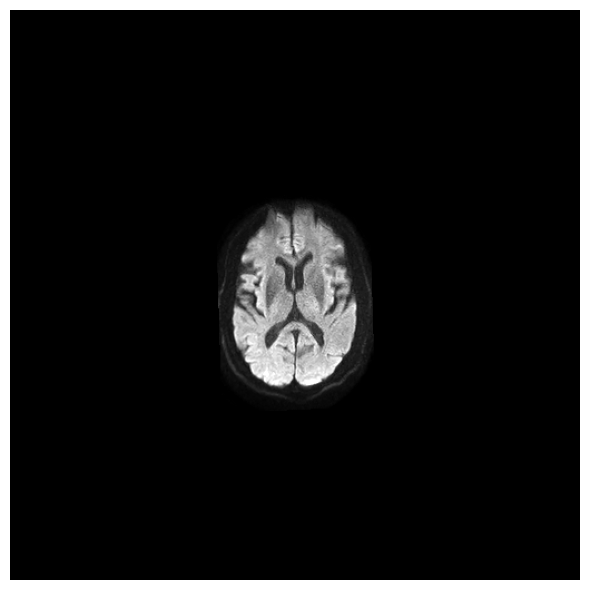

In [2]:
# ===================== Preprocess SOOP Acute Training Set =====================
# - Pairs: strip "_rec-TRACE_dwi" from images; strip "_space-TRACE_desc-lesionAcute_mask" from masks
# - Target shape: per-axis dataset max -> ceil to /16
# - Prep: optional resample (img=linear, mask=nearest), then shared center crop/pad
# - Normalize images (inside non-zero); masks -> binary {0,1}
# - Save preprocessed NIfTI volumes for CNN training (permanent artifacts)

from pathlib import Path
import os, math, logging, json, gc
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom

# ---------------------------- CONFIG -----------------------------------------
IMAGES_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/DWI_images/train")
MASKS_DIR  = Path("/home/rbielski/SOOP/ds004889/acute_only/Acute_mask/train")
OUT_DIR    = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train")

RESAMPLE_TO_TARGET = False   # True -> resample to TARGET_SHAPE before crop/pad
SAVE_AFFINE_FROM = "image"   # "image" or "mask": which affine/header to keep when saving

OUT_DIR.mkdir(parents=True, exist_ok=True)
logging.getLogger("nibabel").setLevel(logging.ERROR)

# ------------------------ Pairing rules (SOOP naming) -------------------------
def _img_key(name: str) -> str:
    s = name[:-7] if name.endswith(".nii.gz") else name
    return s.replace("_rec-TRACE_dwi", "")

def _msk_key(name: str) -> str:
    s = name[:-7] if name.endswith(".nii.gz") else name
    return s.replace("_space-TRACE_desc-lesionAcute_mask", "")

def build_pairs(images_dir: Path, masks_dir: Path):
    imgs = { _img_key(p.name): p for p in sorted(images_dir.glob("*.nii.gz")) if "mask" not in p.name }
    msks = { _msk_key(p.name): p for p in sorted(masks_dir.glob("*.nii.gz")) if "mask" in p.name }
    keys = sorted(set(imgs) & set(msks))
    return [(imgs[k], msks[k]) for k in keys], len(imgs), len(msks), len(keys)

pairs, n_img, n_msk, n_pair = build_pairs(IMAGES_DIR, MASKS_DIR)
print(f"Found: images={n_img}, masks={n_msk}, pairs={n_pair}")
if n_pair == 0:
    raise RuntimeError("No pairs found. Check _img_key/_msk_key rules and directories.")

# ----------------------- Robust 3-D loader & helpers --------------------------
def ensure_3d(vol: np.ndarray) -> np.ndarray:
    """Return a 3-D array. If 4-D with trailing singleton channel/time, squeeze it.
       Raise if still not 3-D afterwards."""
    v = np.asarray(vol)
    # Squeeze ONLY trailing singleton axes beyond 3-D
    while v.ndim > 3 and v.shape[-1] == 1:
        v = v[..., 0]
    if v.ndim != 3:
        raise ValueError(f"Expected 3-D or 4-D with trailing singleton, got shape {vol.shape}")
    return v.astype(np.float32)

def load_nii_3d(path: Path) -> tuple[np.ndarray, nib.Nifti1Image]:
    nii = nib.load(str(path))
    arr = nii.get_fdata()  # may be 3-D or 4-D
    arr3d = ensure_3d(arr)
    return arr3d, nii

def ceil16(x: int) -> int:
    return int(math.ceil(x / 16.0) * 16)

def detect_target_shape(pairs) -> tuple[int,int,int]:
    maxD = maxH = maxW = 0
    for img_p, _ in pairs:
        try:
            arr, _ = load_nii_3d(img_p)
            d, h, w = arr.shape
            maxD, maxH, maxW = max(maxD, d), max(maxH, h), max(maxW, w)
        except Exception:
            pass
    if min(maxD, maxH, maxW) == 0:
        raise RuntimeError("Could not determine target shape (no valid 3-D NIfTI).")
    return (ceil16(maxD), ceil16(maxH), ceil16(maxW))

TARGET_SHAPE = detect_target_shape(pairs)
print("TARGET_SHAPE:", TARGET_SHAPE)

def compute_center_slices(in_shape, out_shape):
    inD, inH, inW = in_shape
    outD, outH, outW = out_shape
    slices = []
    for i_len, o_len in zip((inD,inH,inW), (outD,outH,outW)):
        if i_len >= o_len:
            start = (i_len - o_len)//2
            end   = start + o_len
            slices.append(slice(start, end))
        else:
            slices.append(slice(0, i_len))
    return tuple(slices)

def center_crop_or_pad(vol: np.ndarray, in_slices, out_shape) -> np.ndarray:
    """Shared crop/pad to exact out_shape (3-D in, 3-D out)."""
    assert vol.ndim == 3, f"center_crop_or_pad expects 3-D, got {vol.shape}"
    sub = vol[in_slices[0], in_slices[1], in_slices[2]]
    out = np.zeros(out_shape, dtype=vol.dtype)
    offs = tuple((o - s)//2 for s, o in zip(sub.shape, out_shape))
    out[
        offs[0]:offs[0]+sub.shape[0],
        offs[1]:offs[1]+sub.shape[1],
        offs[2]:offs[2]+sub.shape[2]
    ] = sub
    return out

def resample_to_shape(vol: np.ndarray, out_shape: tuple[int,int,int], order: int) -> np.ndarray:
    """Resample 3-D volume to out_shape with given interpolation order.
       order=1 for images (linear), order=0 for masks (nearest)."""
    assert vol.ndim == 3, "resample_to_shape expects 3-D"
    if vol.shape == out_shape:
        return vol
    zf = tuple(o / i for o,i in zip(out_shape, vol.shape))
    # mode='nearest' prevents edge artifacts; prefilter off for speed with linear/nearest
    return zoom(vol, zf, order=order, mode="nearest", prefilter=False)

def normalize_image(img: np.ndarray) -> np.ndarray:
    """Normalize inside non-zero region: clip [p1,p99], z-score, min-max to [0,1]."""
    if img.size == 0 or np.max(img) == 0:
        return np.zeros_like(img, dtype=np.float32)
    nz = img[img > 0]
    if nz.size == 0:
        return np.zeros_like(img, dtype=np.float32)
    p1, p99 = np.percentile(nz, [1, 99])
    img = np.clip(img, p1, p99)
    m, s = nz.mean(), nz.std()
    if s > 0:
        img = (img - m) / s
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    else:
        img = np.zeros_like(img)
    return img.astype(np.float32)

# -------------------------- Core preparation ----------------------------------
def prepare_pair(img_vol: np.ndarray, msk_vol: np.ndarray,
                 target_shape: tuple[int,int,int],
                 resample: bool):
    """Make image & mask same shape and target-ready (3-D in, 3-D out)."""
    # 1) Ensure same incoming spatial shape
    if img_vol.shape != msk_vol.shape:
        # Align mask to image by shared crop/pad to image shape
        s = compute_center_slices(msk_vol.shape, img_vol.shape)
        msk_vol = center_crop_or_pad(msk_vol, s, img_vol.shape)

    # 2) Optional resample both to target (img linear, mask nearest)
    if resample and img_vol.shape != target_shape:
        img_vol = resample_to_shape(img_vol, target_shape, order=1)
        msk_vol = resample_to_shape(msk_vol, target_shape, order=0)

    # 3) Final shared crop/pad to exact target (no resample path)
    if img_vol.shape != target_shape:
        s = compute_center_slices(img_vol.shape, target_shape)
        img_vol = center_crop_or_pad(img_vol, s, target_shape)
        msk_vol = center_crop_or_pad(msk_vol, s, target_shape)
    elif msk_vol.shape != target_shape:
        s = compute_center_slices(msk_vol.shape, target_shape)
        img_vol = center_crop_or_pad(img_vol, s, target_shape)
        msk_vol = center_crop_or_pad(msk_vol, s, target_shape)

    # 4) Normalize image, binarize mask
    img_vol = normalize_image(img_vol)
    msk_vol = (msk_vol > 0.5).astype(np.float32)
    return img_vol, msk_vol

# --------------------------- Processing loop ----------------------------------
def option_label(img_path: Path, msk_path: Path) -> str:
    base = os.path.basename(msk_path)
    if "_label" in base:
        base = base.split("_label")[0]
    elif "_mask" in base:
        base = base.split("_mask")[0]
    return base

def save_nifti(arr: np.ndarray, like: nib.Nifti1Image, out_path: Path):
    """Save arr with affine/header from 'like' image."""
    nii = nib.Nifti1Image(arr.astype(np.float32), affine=like.affine, header=like.header)
    nib.save(nii, str(out_path))

meta = {
    "images_dir": str(IMAGES_DIR),
    "masks_dir": str(MASKS_DIR),
    "out_dir": str(OUT_DIR),
    "target_shape": TARGET_SHAPE,
    "resample_to_target": RESAMPLE_TO_TARGET,
    "saved_affine_from": SAVE_AFFINE_FROM,
    "pairs": n_pair
}
(out_meta := OUT_DIR / "preprocess_meta.json").write_text(json.dumps(meta, indent=2))
print(f"Will write metadata to: {out_meta}")

ok = 0
for img_p, msk_p in pairs:
    try:
        # Load both as 3-D
        img3d, img_nii = load_nii_3d(img_p)
        msk3d, msk_nii = load_nii_3d(msk_p)

        # Prepare
        img_prep, msk_prep = prepare_pair(img3d, msk3d, TARGET_SHAPE, RESAMPLE_TO_TARGET)

        # Output filenames
        key = option_label(img_p, msk_p)
        out_img = OUT_DIR / f"{key}_img_prepped.nii.gz"
        out_msk = OUT_DIR / f"{key}_mask_prepped.nii.gz"

        like = img_nii if SAVE_AFFINE_FROM == "image" else msk_nii
        save_nifti(img_prep, like, out_img)
        save_nifti(msk_prep, like, out_msk)
        ok += 1

    except Exception as e:
        print(f"⚠️  Failed {img_p.name}: {e}")

    # keep memory tidy
    del img3d, msk3d
    gc.collect()

print(f"Done. Wrote {ok} preprocessed pairs to: {OUT_DIR}")

# ----------------------------- Quick viewer (optional) ------------------------
# Shows one pair after preprocessing to sanity-check overlay
try:
    import matplotlib.pyplot as plt
    sample_img = next(OUT_DIR.glob("*_img_prepped.nii.gz"))
    sample_msk = Path(str(sample_img).replace("_img_prepped.nii.gz", "_mask_prepped.nii.gz"))
    i = nib.load(str(sample_img)).get_fdata().astype(np.float32)
    m = nib.load(str(sample_msk)).get_fdata().astype(np.float32) > 0.5
    z = i.shape[2]//2
    plt.figure(figsize=(6,6))
    plt.imshow(i[:,:,z].T, cmap="gray", origin="lower")
    plt.contour(m[:,:,z].T, levels=[0.5], linewidths=0.7, colors="r")
    plt.axis("off"); plt.tight_layout(); plt.show()
except StopIteration:
    pass


In [1]:
# ==== Preprocessed viewer (overlay + affine check against *raw* pair) ========
# Works directly on the preprocessed volumes you just wrote.
# Also finds the corresponding *raw* image/mask to print both affines.

from pathlib import Path
import os, math, json, logging, numpy as np, nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output
from functools import lru_cache
from scipy.ndimage import binary_dilation

logging.getLogger("nibabel").setLevel(logging.ERROR)

# --- update these three paths if yours differ --------------------------------
RAW_IMAGES_DIR = Path("/home/rbielski/SOOP/ds004889/acute_only/DWI_images/train")
RAW_MASKS_DIR  = Path("/home/rbielski/SOOP/ds004889/acute_only/Acute_mask/train")
OUT_DIR        = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train")

# --- utility: how we key / pair raw files (same rules you used earlier) -----
def _img_key(name: str) -> str:
    s = name[:-7] if name.endswith(".nii.gz") else name
    return s.replace("_rec-TRACE_dwi", "")

def _msk_key(name: str) -> str:
    s = name[:-7] if name.endswith(".nii.gz") else name
    return s.replace("_space-TRACE_desc-lesionAcute_mask", "")

# --- find preprocessed pairs --------------------------------------------------
pp_imgs  = sorted(OUT_DIR.glob("*_img_prepped.nii.gz"))
pp_masks = sorted(OUT_DIR.glob("*_mask_prepped.nii.gz"))

# Map key → preprocessed paths
def _pp_key_from_name(p: Path) -> str:
    # Remove suffix we added when saving
    n = p.name.replace("_img_prepped.nii.gz", "").replace("_mask_prepped.nii.gz", "")
    return n

PP = {}
for p in pp_imgs:  PP.setdefault(_pp_key_from_name(p), {})["img"]  = p
for p in pp_masks: PP.setdefault(_pp_key_from_name(p), {})["mask"] = p
PP = {k:v for k,v in PP.items() if "img" in v and "mask" in v}

if not PP:
    raise RuntimeError(f"No preprocessed *_img_prepped/*.nii.gz found in {OUT_DIR}")

# --- build a map from key → raw image/mask for affine checking ----------------
raw_imgs = {_img_key(p.name): p for p in RAW_IMAGES_DIR.glob("*.nii.gz") if "mask" not in p.name}
raw_msks = {_msk_key(p.name): p for p in RAW_MASKS_DIR.glob("*.nii.gz") if "mask" in p.name}

RAW = {}
for k in PP.keys():
    # Try exact match first; if not present, fall back to best-effort prefix match
    if k in raw_imgs and k in raw_msks:
        RAW[k] = {"img": raw_imgs[k], "mask": raw_msks[k]}
    else:
        # relaxed matching
        cand_i = next((p for kk,p in raw_imgs.items() if kk in k or k in kk), None)
        cand_m = next((p for kk,p in raw_msks.items() if kk in k or k in kk), None)
        if cand_i and cand_m:
            RAW[k] = {"img": cand_i, "mask": cand_m}

# --- read target shape from metadata if present -------------------------------
meta_path = OUT_DIR / "preprocess_meta.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    TARGET_SHAPE = tuple(meta.get("target_shape", ()))
else:
    # Infer from any preprocessed image
    shp = nib.load(str(next(iter(PP.values()))["img"])).shape
    TARGET_SHAPE = shp[:3]

# --- io helpers ---------------------------------------------------------------
@lru_cache(maxsize=64)
def _load_nii(path: str) -> np.ndarray:
    arr = nib.load(path).get_fdata().astype(np.float32)
    # squeeze a stray channel dim if present
    if arr.ndim == 4 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr

def _normalize_image(img: np.ndarray) -> np.ndarray:
    if img.size == 0 or np.max(img) == 0:
        return np.zeros_like(img, dtype=np.float32)
    nz = img[img > 0]
    if nz.size == 0:
        return np.zeros_like(img, dtype=np.float32)
    p1, p99 = np.percentile(nz, [1, 99])
    img = np.clip(img, p1, p99)
    m, s = nz.mean(), nz.std()
    if s > 0: img = (img - m) / s
    mn, mx = img.min(), img.max()
    img = (img - mn) / (mx - mn + 1e-8)
    return img.astype(np.float32)

def _edges2d(m):
    m = m.astype(bool)
    return binary_dilation(m) & (~m)

# --- widget UI ----------------------------------------------------------------
keys_sorted = sorted(PP.keys())
pair_dd = W.Dropdown(options=keys_sorted, description="Case:", layout=W.Layout(width="100%"))
axis_rb = W.RadioButtons(options=[("Axial (z)", 2), ("Coronal (y)", 1), ("Sagittal (x)", 0)],
                         value=2, description="Axis:")
slice_sl = W.IntSlider(description="Slice:", min=0, max=1, value=0, continuous_update=False)
alpha_sl = W.FloatSlider(description="Mask α:", min=0.0, max=1.0, step=0.05, value=0.55)
edges_cb = W.Checkbox(description="Edges only", value=True)
invert_cb = W.Checkbox(description="Invert image", value=False)
status = W.HTML(f"<b>Preprocessed viewer</b> — cases: {len(keys_sorted)} | target: {TARGET_SHAPE}")

controls = W.VBox([status, W.HBox([axis_rb, slice_sl]), pair_dd, W.HBox([alpha_sl, edges_cb, invert_cb])])
out = W.Output()

def _update_slider_range(*_):
    try:
        k = pair_dd.value
        img = _load_nii(str(PP[k]["img"]))
        ax = axis_rb.value
        slice_sl.max = int(img.shape[ax] - 1)
        slice_sl.value = min(slice_sl.value, slice_sl.max)
    except Exception as e:
        slice_sl.max = 0
        slice_sl.value = 0
        with out:
            clear_output(wait=True)
            print("Error (range):", e)

def _extract_2d(vol, axis, idx):
    """vol is 3D (D,H,W). Return a 2D slice with (H,W) orientation for plotting."""
    if axis == 2:    # axial z
        s = vol[:, :, idx]
    elif axis == 1:  # coronal y
        s = vol[:, idx, :]
    else:            # sagittal x
        s = vol[idx, :, :]
    return s

def _redraw(*_):
    with out:
        clear_output(wait=True)
        try:
            k = pair_dd.value
            ip = PP[k]["img"]; mp = PP[k]["mask"]
            img = _load_nii(str(ip)); msk = _load_nii(str(mp)) > 0.5

            # normalize preprocessed image (viewer only; files are already normalized if you saved them so)
            img_v = _normalize_image(img.copy())
            if invert_cb.value: img_v = 1.0 - img_v

            ax, idx = axis_rb.value, int(slice_sl.value)
            img2d = _extract_2d(img_v, ax, idx)
            m2d   = _extract_2d(msk.astype(np.uint8), ax, idx).astype(bool)

            # status line (also show raw dims if we can find originals)
            raw_info = ""
            if k in RAW:
                ri = nib.load(str(RAW[k]["img"]))
                rm = nib.load(str(RAW[k]["mask"]))
                raw_info = f" | raw(img/msk): {ri.shape[:3]}/{rm.shape[:3]}"

            status.value = (f"<b>Preprocessed viewer</b> — cases: {len(keys_sorted)} "
                            f"| prep: {img.shape[:3]}{raw_info}")

            # plot
            plt.figure(figsize=(6,6))
            plt.imshow(img2d.T, cmap="gray", origin="lower")
            if edges_cb.value:
                e = _edges2d(m2d)
                plt.contour(e.T, levels=[0.5], linewidths=0.7, colors="r")
            else:
                plt.imshow(np.ma.masked_where(~m2d.T, m2d.T), cmap="jet",
                           alpha=float(alpha_sl.value), origin="lower")
            plt.axis("off"); plt.tight_layout(); plt.show(); plt.close()

            # affine check against RAW (world alignment)
            if k in RAW:
                img_nii = nib.load(str(RAW[k]["img"]))
                msk_nii = nib.load(str(RAW[k]["mask"]))
                print("Raw image affine:\n", img_nii.affine)
                print("Raw mask  affine:\n", msk_nii.affine)
                if np.allclose(img_nii.affine, msk_nii.affine):
                    print("✅ Raw affines match (same voxel-to-world mapping).")
                else:
                    print("⚠️ Raw affines differ — masks may be in a different space.")

                # also show preprocessed affines (you saved them to match image space)
                ppi = nib.load(str(ip)); ppm = nib.load(str(mp))
                print("\nPreprocessed image affine:\n", ppi.affine)
                print("Preprocessed mask  affine:\n", ppm.affine)
                if np.allclose(ppi.affine, ppm.affine):
                    print("✅ Preprocessed affines match.")
                else:
                    print("⚠️ Preprocessed affines differ (unexpected).")

        except Exception as e:
            print("Error (draw):", e)

# wire up
pair_dd.observe(_update_slider_range, names="value")
pair_dd.observe(_redraw, names="value")
axis_rb.observe(_update_slider_range, names="value")
axis_rb.observe(_redraw, names="value")
slice_sl.observe(_redraw, names="value")
alpha_sl.observe(_redraw, names="value")
edges_cb.observe(_redraw, names="value")
invert_cb.observe(_redraw, names="value")

_update_slider_range()
_redraw()
display(controls, out)
# ============================================================================


Output()

In [ ]:

"""
DWI Stroke Lesion Segmentation (Dynamic Input Version)

This training script builds upon prior production and cropped variants but adds
support for arbitrary volumetric input sizes.  It automatically determines
the largest spatial dimensions present in a dataset and pads smaller volumes
so that all inputs share the same shape.  The script retains detailed
logging, memory monitoring, data augmentation and custom layers from the
previous versions while incorporating recommendations from the latest model
evaluation:

* Dice/boundary loss weights adjusted to emphasise boundary precision
* Over‑segmentation mitigation via adjustable decision threshold
* Slightly stronger augmentation (rotations/flips/gamma) when overfitting
  is suspected
* Tunable L2 regularisation and dropout rates
* Longer warm‑up and lower minimum learning rate

The batch size is fixed at 2, but input volumes may be of any shape as long
as the corresponding mask has identical dimensions.  All three spatial
dimensions are padded to the maximum observed size for consistent training.
"""

import os
import sys
import logging
from pathlib import Path

# ---- Environment (set BEFORE importing TensorFlow) ----
import os

# Keep: quiet logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Optional: better GPU allocator (helps reduce fragmentation on long runs)
# Works with TF 2.10+ built for CUDA 11/12.
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Don't set for normal training:
# - CUDA_LAUNCH_BLOCKING=1  # debug-only; forces sync and can make training very slow
# - TF_XLA_FLAGS / XLA_FLAGS  # generally unnecessary on TF 2.20; can cause confusion
# - TF_ENABLE_ONEDNN_OPTS=0  # controls CPU-only kernels; leave default unless you need bit-for-bit CPU numerics


import tensorflow as tf

# See GPUs and enable memory growth (good practice)
gpus = tf.config.list_physical_devices("GPU")
print("Visible GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Could not set memory growth on {gpu}: {e}")

# Optional: use all visible GPUs
strategy = tf.distribute.MirroredStrategy() if gpus else tf.distribute.get_strategy()
print("Strategy:", type(strategy).__name__)

# Build/compile inside the scope if you use strategy
# with strategy.scope():
#     model = ...
#     model.compile(...)



# ---------------------------------------------------------------------------
# Logging configuration
# ---------------------------------------------------------------------------
# Use two file handlers and one stream handler.  One file captures all
# high‑level events (INFO and above) and the other captures per‑process
# debugging output.  A console stream is kept for quick feedback.
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/smart_sota_dynamic.log'),
        logging.FileHandler(f'logs/training_dynamic_{os.getpid()}.debug.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger('SmartSOTA_Dynamic')
logger.setLevel(logging.DEBUG)

# ---------------------------------------------------------------------------
# Imports with graceful degradation
# ---------------------------------------------------------------------------
try:
    import tensorflow as tf
    from tensorflow.keras import layers
    import numpy as np
    import nibabel as nib
    from scipy.ndimage import zoom, binary_dilation, rotate
    from sklearn.model_selection import KFold
    from skimage import measure
    import json
    import time
    import math
    import random
    import gc
    import psutil
    from functools import lru_cache
    from concurrent.futures import ThreadPoolExecutor
    logger.info("✅ All imports successful")
except ImportError as e:
    logger.critical(f"❌ Import failed: {e}")
    sys.exit(1)

# ---------------------------------------------------------------------------
# Runtime configuration
# ---------------------------------------------------------------------------
# Disable eager execution for performance and to avoid certain CUDNN issues.
tf.config.run_functions_eagerly(False)
logger.info(f"TensorFlow eager execution: {tf.executing_eagerly()}")

warnings_to_ignore = [UserWarning, DeprecationWarning, FutureWarning]
for w in warnings_to_ignore:
    tf.autograph.set_verbosity(0)
import warnings
for w in warnings_to_ignore:
    warnings.filterwarnings("ignore", category=w)
warnings.filterwarnings("ignore", module="nibabel")

logger.info(
    f"Environment verified:\n"
    f"- Python {sys.version}\n"
    f"- TensorFlow {tf.__version__}\n"
    f"- NumPy {np.__version__}\n"
    f"- GPU devices: {len(tf.config.list_physical_devices('GPU'))}"
)

# ---------------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------------
class DynamicTrainingConfig:
    """Configuration class supporting variable input shapes.

    The first call to `detect_input_shape` will populate INPUT_SHAPE based on
    observed dataset maxima.  All other hyperparameters may be tuned from
    outside to reflect recommendations from prior evaluations.
    """

    DATA_DIR: Path   = Path("/home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train")
    IMAGES_DIR: Path = DATA_DIR   # same folder
    MASKS_DIR: Path  = DATA_DIR   # same folder


    # The input shape will be set by detect_input_shape; default to None
    INPUT_SHAPE = None

    # Data split configuration
    VALIDATION_SPLIT = 0.15
    SMALL_LESION_THRESHOLD = 100

    # Training schedule
    BATCH_SIZE = 2
    INITIAL_EPOCH = 0
    TOTAL_EPOCHS = 200
    INITIAL_LR = 1e-4
    MIN_LR = 5e-7               # Lower minimum LR for potential late training plateaus
    WARMUP_EPOCHS = 15          # Extended warmup
    MAX_GRAD_NORM = 1.0

    # Model architecture
    BASE_FILTERS = 8
    DROPOUT_RATE = 0.55         # Balanced dropout for robustness
    L2_REG = 1.5e-3             # Moderate L2 regularisation
    MAMBA_DEPTH = 2
    SAM_HEADS = 4

    # Data augmentation
    AUGMENTATION_INTENSITY = 0.5
    SYNTHETIC_LESION_PROB = 0.3
    ROTATION_RANGE = 20         # Slightly larger range than original

    # Loss configuration (based on evaluation recommendations)
    USE_BOUNDARY_LOSS = True
    DICE_LOSS_WEIGHT = 0.4
    BOUNDARY_LOSS_WEIGHT = 0.6
    DEEP_SUPERVISION_WEIGHTS = [0.1, 0.2, 0.3]
    
    #Tweaks
    # Add these defaults anywhere among the other hyperparams:
    DICE_WEIGHT: float = 0.4
    BOUNDARY_WEIGHT: float = 0.6
    # inside class DynamicTrainingConfig:
    RESAMPLE_TO_TARGET = True   # resample both image & mask to INPUT_SHAPE[:-1]


    # Decision threshold for converting logits to binary masks
    DECISION_THRESHOLD = 0.5    # Raise threshold to mitigate over‑segmentation

    # Output directories
    MODEL_DIR = Path("models/dynamic_production")
    CALLBACKS_DIR = Path("callbacks/dynamic_production")

    def __init__(self):
        # Timestamp for saving model checkpoints
        self.timestamp = time.strftime("%Y%m%d_%H%M%S")
        self.MODEL_DIR.mkdir(parents=True, exist_ok=True)
        self.CALLBACKS_DIR.mkdir(parents=True, exist_ok=True)
        # Write config to JSON for reproducibility
        config_dict = {k: v for k, v in self.__dict__.items()
                      if not k.startswith('__') and not callable(v)}
        with open(self.MODEL_DIR / "config.json", "w") as f:
            json.dump(config_dict, f, indent=2, default=str)
        logger.info(
            f"📋 DynamicTrainingConfig initialised:\n"
            f"   Images directory: {self.IMAGES_DIR}\n"
            f"   Masks directory: {self.MASKS_DIR}\n"
            f"   Batch size: {self.BATCH_SIZE}\n"
            f"   Warmup epochs: {self.WARMUP_EPOCHS}\n"
            f"   Minimum LR: {self.MIN_LR}\n"
            f"   Dice/boundary weights: {self.DICE_LOSS_WEIGHT}:{self.BOUNDARY_LOSS_WEIGHT}\n"
        )

    @property
    def model_path(self) -> Path:
        return self.MODEL_DIR / f"smart_sota_dynamic_{self.timestamp}.keras"

    
    @property
    def checkpoint_path(self) -> Path:
        return self.CALLBACKS_DIR / "best_model_dynamic.weights.h5"



# ---------------------------------------------------------------------------
# Custom layers (identical to previous implementations)
# ---------------------------------------------------------------------------
# put this once near the top (same place you imported for losses)
try:
    from keras.saving import register_keras_serializable
except Exception:
    from tensorflow.keras.utils import register_keras_serializable  # fallback


@register_keras_serializable(package="custom")
class ResidualConvBlock(layers.Layer):
    """Residual block using LayerNorm (more stable than BN for very small batches)."""
    def __init__(self, filters, kernel_reg=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_reg = kernel_reg

    def build(self, input_shape):
        self.conv1 = layers.Conv3D(self.filters, 3, padding='same',
                                   kernel_regularizer=self.kernel_reg)
        self.ln1 = layers.LayerNormalization(epsilon=1e-5)
        self.conv2 = layers.Conv3D(self.filters, 3, padding='same',
                                   kernel_regularizer=self.kernel_reg)
        self.ln2 = layers.LayerNormalization(epsilon=1e-5)
        self.dropout = layers.SpatialDropout3D(0.1)
        self.residual_conv = layers.Conv3D(self.filters, 1, padding='same')
        self.residual_ln = layers.LayerNormalization(epsilon=1e-5)
        super().build(input_shape)

    def call(self, inputs, training=None):
        x = self.conv1(inputs)
        x = self.ln1(x)
        x = tf.nn.relu(x)
        x = self.dropout(x, training=training)
        x = self.conv2(x)
        x = self.ln2(x)
        residual = self.residual_conv(inputs)
        residual = self.residual_ln(residual)
        return tf.nn.relu(x + residual)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_reg": tf.keras.regularizers.serialize(self.kernel_reg)
                           if self.kernel_reg else None
        })
        return config


@register_keras_serializable(package="custom")
class VisionMambaBlock(layers.Layer):
    """Efficient vision Mamba block with dynamic input support"""
    def __init__(self, filters, kernel_size=3, expansion=2, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.expansion = expansion

    def build(self, input_shape):
        self.in_conv = layers.Conv3D(
            self.filters * self.expansion,
            1,
            use_bias=False,
            padding='same',
            data_format='channels_last')
        self.spatial_conv = layers.Conv3D(
            self.filters * self.expansion,
            self.kernel_size,
            padding='same',
            use_bias=False,
            data_format='channels_last')
        self.out_conv = layers.Conv3D(
            self.filters, 1,
            padding='same',
            data_format='channels_last')
        self.norm = layers.LayerNormalization()
        self.dropout = layers.SpatialDropout3D(0.1)
        super().build(input_shape)

    def call(self, inputs, training=None):
        x = self.in_conv(inputs)
        x = tf.nn.relu(x)
        x = self.spatial_conv(x)
        x = tf.cast(tf.nn.relu(x), inputs.dtype)
        x = self.dropout(x, training=training)
        x = self.out_conv(x)
        x = self.norm(x)
        return x + inputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "expansion": self.expansion
        })
        return config

@register_keras_serializable(package="custom")
class SAM2Attention(layers.Layer):
    """Enhanced SAM2 attention with hierarchical memory banks"""
    def __init__(self, filters, heads, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.heads = heads
        self.depth = filters // heads
        if filters % heads != 0:
            raise ValueError("Filters must be divisible by heads")

    def build(self, input_shape):
        self.query = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.key = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.value = layers.Conv3D(self.filters, 1, data_format='channels_last')
        self.out_conv = layers.Conv3D(input_shape[-1], 1, data_format='channels_last')
        self.memory_bank = self.add_weight(
            name='memory_bank',
            shape=(1, 1, 1, 1, self.filters),
            initializer='zeros',
            trainable=True
        )
        self.dropout = layers.SpatialDropout3D(0.1)
        super().build(input_shape)

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        depth_dim = tf.shape(inputs)[3]
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)
        k = k + self.memory_bank
        v = v + self.memory_bank
        q = self._split_heads_safe(q, batch_size, height, width, depth_dim)
        k = self._split_heads_safe(k, batch_size, height, width, depth_dim)
        v = self._split_heads_safe(v, batch_size, height, width, depth_dim)
        dk = tf.cast(self.depth, q.dtype)
        attn_logits = tf.matmul(q, k, transpose_b=True)
        attn_logits = attn_logits / tf.math.sqrt(dk)
        attn_weights = tf.nn.softmax(attn_logits, axis=-1)
        attn_output = tf.matmul(attn_weights, v)
        attn_output = self._combine_heads_safe(attn_output, batch_size, height, width, depth_dim)
        output = self.out_conv(attn_output)
        output = self.dropout(output, training=training)
        return output + inputs

    def _split_heads_safe(self, x, batch_size, height, width, depth_dim):
        x = tf.reshape(x, [batch_size, height, width, depth_dim, self.heads, self.depth])
        return tf.transpose(x, perm=[0, 4, 1, 2, 3, 5])

    def _combine_heads_safe(self, x, batch_size, height, width, depth_dim):
        x = tf.transpose(x, perm=[0, 2, 3, 4, 1, 5])
        return tf.reshape(x, [batch_size, height, width, depth_dim, self.filters])

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "heads": self.heads
        })
        return config

# ---------------------------------------------------------------------------
# Build the segmentation model (UNet-like with your custom blocks)
# ---------------------------------------------------------------------------
def build_dynamic_model(config: DynamicTrainingConfig) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=config.INPUT_SHAPE)  # (D,H,W,1)

    x = inputs
    skips = []
    filters = config.BASE_FILTERS

    # Encoder
    for _ in range(4):
        x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
        x = VisionMambaBlock(filters)(x)
        skips.append(x)
        x = layers.MaxPool3D(pool_size=2)(x)
        filters *= 2

    # Bottleneck
    x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
    x = SAM2Attention(filters, heads=config.SAM_HEADS)(x)

    # Decoder
    for d in reversed(range(4)):
        filters //= 2
        x = layers.UpSampling3D(size=2)(x)
        x = layers.Concatenate()([x, skips[d]])
        x = ResidualConvBlock(filters, kernel_reg=tf.keras.regularizers.l2(config.L2_REG))(x)
        x = VisionMambaBlock(filters)(x)

    # IMPORTANT: output logits (no activation). Dice in your loss applies sigmoid.
    # Build model – replace the head
    outputs = layers.Conv3D(1, kernel_size=1, activation="sigmoid", name="probs")(x)


    return tf.keras.Model(inputs=inputs, outputs=outputs, name="SmartSOTA_Dynamic")



# ---------------------------------------------------------------------------
# Utility functions for memory monitoring
# ---------------------------------------------------------------------------
def log_memory_usage(stage: str) -> None:
    process = psutil.Process(os.getpid())
    gb_used = process.memory_info().rss / 1024**3
    gpu_mem = []
    try:
        for i in range(4):
            alloc = tf.config.experimental.get_memory_info(f'GPU:{i}')
            gpu_mem.append(f"GPU{i}: {alloc['current']/1e9:.2f}GB")
    except Exception:
        gpu_mem = ["GPU mem tracking failed"]
    try:
        disk_usage = psutil.disk_usage('/')
        disk_free_gb = disk_usage.free / 1024**3
        disk_info = f"Disk: {disk_free_gb:.1f}GB free"
    except Exception:
        disk_info = "Disk: unavailable"
    logger.info(f"Memory at {stage}: CPU={gb_used:.2f}GB | {' | '.join(gpu_mem)} | {disk_info}")


# ---------------------------------------------------------------------------
# Dataset inspection and loading
# ---------------------------------------------------------------------------
from pathlib import Path
import numpy as np
import nibabel as nib
import gc



def detect_input_shape(data_dir: Path) -> tuple:
    """
    Determine the maximum spatial (D,H,W) across NIfTI volumes under `data_dir`,
    then round each dimension UP to the nearest multiple of 16.

    We consider any .nii.gz with at least 3 dims. If none are valid, an error is raised.
    Logs fall back to print() if a global `logger` isn't available.
    """
    import math
    import nibabel as nib

    log = globals().get("logger", None)
    def _info(msg: str):
        if log is not None:
            log.info(msg)
        else:
            print(msg)

    _info("🔍 Detecting input shape from dataset…")

    # Scan all NIfTI files under the root (Images/Masks are fine; we only read headers/shapes)
    image_files = list(data_dir.rglob("*.nii.gz"))
    max_shape = [0, 0, 0]
    invalid = []

    if not image_files:
        raise FileNotFoundError(f"No .nii.gz files found under {data_dir}")

    for f in image_files:
        try:
            img = nib.load(str(f))
            shp = img.shape
            # Need at least 3 spatial dims
            if len(shp) >= 3:
                for i in range(3):
                    max_shape[i] = max(max_shape[i], int(shp[i]))
            else:
                invalid.append(f"{f.name}: shape {shp} has fewer than 3 dims")
        except Exception as e:
            invalid.append(f"{f.name}: failed to load ({e})")

    if all(dim == 0 for dim in max_shape):
        details = ("Issues encountered:\n  - " + "\n  - ".join(invalid)) if invalid else "No details."
        raise RuntimeError(f"No valid 3-D NIfTI files found in {data_dir}. {details}")

    def _ceil16(x: int) -> int:
        return int(math.ceil(x / 16.0) * 16)

    rounded_shape = tuple(_ceil16(dim) for dim in max_shape)

    _info(
        f"📐 Detected max volume dimensions: {tuple(max_shape)} → "
        f"rounded up to: {rounded_shape}"
    )
    return rounded_shape


0
# --- Flexible loader: supports single-folder (preprocessed) or two-folder (raw) ---
import gc, re, json
import numpy as np
import nibabel as nib
from pathlib import Path

def load_generic_dataset(config: DynamicTrainingConfig):
    """
    Supports two layouts:

    (A) Preprocessed single folder (both live in DATA_DIR):
        - images like: sub-XXX_rec-TRACE_dwi[_prepped].nii.gz or sub-XXX_space-TRACE_desc-lesionAcute_img_prepped.nii.gz
        - masks  like: sub-XXX_space-TRACE_desc-lesionAcute_mask[_prepped].nii.gz

    (B) Raw two-folder SOOP layout:
        - IMAGES_DIR: *_rec-TRACE_dwi.nii.gz
        - MASKS_DIR : *_space-TRACE_desc-lesionAcute_mask.nii.gz

    Pairing is by base key (strip modality-specific suffixes & optional '_prepped').
    """
    logger.info("📚 Loading SOOP dataset (flex loader)…")
    log_memory_usage("dataset_load_start")

    base = config.DATA_DIR
    images_dir = getattr(config, "IMAGES_DIR", None)
    masks_dir  = getattr(config, "MASKS_DIR", None)

    # Decide layout
    single_folder_mode = False
    if images_dir is None or masks_dir is None or (images_dir == base and masks_dir == base):
        single_folder_mode = True
        images_dir = base
        masks_dir  = base

    # --- key functions that tolerate both raw and prepped names
    def strip_ext(name):
        return name[:-7] if name.endswith(".nii.gz") else name

    # For preprocessed files in single folder mode
    def prepped_key(name: str) -> str:
        """Extract the common key part from preprocessed image/mask filenames."""
        base_name = strip_ext(name)
        # Remove _img_prepped or _mask_prepped, preserving the common part
        if "_img_prepped" in base_name:
            return base_name.replace("_img_prepped", "")
        elif "_mask_prepped" in base_name:
            return base_name.replace("_mask_prepped", "")
        return base_name  # fallback

    # Raw image suffix and optional "_prepped"
    IMG_PATTERNS = [
        r"_rec-TRACE_dwi(?:_prepped)?$",
        r"_T1w(?:_prepped)?$",                    # allow future T1w usage
        r"(?:_image|_img)(?:_prepped)?$"         # generic image export
    ]
    # Raw mask suffix and optional "_prepped"
    MSK_PATTERNS = [
        r"_space-TRACE_desc-lesionAcute_mask(?:_prepped)?$",
        r"(?:_mask|_label|_seg)(?:_prepped)?$"   # generic mask export
    ]

    def _strip_with_patterns(stem, pats):
        for p in pats:
            s = re.sub(p, "", stem)
            if s != stem:
                return s
        return stem  # fallback: no change

    def img_key(p: Path) -> str:
        stem = strip_ext(p.name)
        # For preprocessed files, use more specific pattern
        if "_img_prepped" in stem:
            return prepped_key(p.name)
        return _strip_with_patterns(stem, IMG_PATTERNS)

    def msk_key(p: Path) -> str:
        stem = strip_ext(p.name)
        # For preprocessed files, use more specific pattern
        if "_mask_prepped" in stem:
            return prepped_key(p.name)
        return _strip_with_patterns(stem, MSK_PATTERNS)

    # --- collect candidates
    if single_folder_mode:
        all_niis = sorted(images_dir.glob("*.nii.gz"))
        images = [p for p in all_niis if re.search(r"(rec-TRACE_dwi|_img|_image|T1w)", p.name)]
        masks  = [p for p in all_niis if re.search(r"(mask|label|seg|desc-lesionAcute_mask)", p.name)]
        logger.info(f"📁 Single-folder mode: {len(images)} images, {len(masks)} masks in {images_dir}")
    else:
        images = sorted([p for p in images_dir.glob("*.nii.gz") if "_rec-TRACE_dwi" in p.name])
        masks  = sorted([p for p in masks_dir.glob("*.nii.gz")  if "_desc-lesionAcute_mask" in p.name or "mask" in p.name])
        logger.info(f"📂 Two-folder mode: images={len(images)} ({images_dir}), masks={len(masks)} ({masks_dir})")

    # Debug info
    logger.info(f"Found {len(images)} image files and {len(masks)} mask files")

    img_map = {img_key(p): p for p in images}
    msk_map = {msk_key(p): p for p in masks}
    keys = sorted(set(img_map).intersection(msk_map.keys()))

    # More debug info
    logger.info(f"After key matching: {len(keys)} pairs identified")

    if not keys:
        # help debug
        logger.error("No image–mask pairs matched. Examples:")
        for k, v in list(img_map.items())[:5]:
            logger.error(f"  IMG key {k} -> {v.name}")
        for k, v in list(msk_map.items())[:5]:
            logger.error(f"  MSK key {k} -> {v.name}")
        raise RuntimeError("No pairs matched. Check filename patterns / key rules.")

    # Rest of function remains the same...
    pairs, lesion_counts = [], []
    for k in keys:
        img_p, msk_p = img_map[k], msk_map[k]
        try:
            mask_obj = nib.load(str(msk_p))
            has_lesion = bool(np.any(mask_obj.get_fdata() > 0))
            lesion_counts.append(1 if has_lesion else 0)
            pairs.append((img_p, msk_p))
        except Exception as e:
            logger.warning(f"Skipping pair for {k}: {e}")
        finally:
            try: del mask_obj
            except: pass
            gc.collect()

    logger.info(f"📊 Created {len(pairs)} image–mask pairs")
    if lesion_counts:
        logger.info(f"🧠 Lesion presence: {np.mean(lesion_counts)*100:.2f}%")
    log_memory_usage("dataset_load_end")
    return pairs, np.array(lesion_counts, dtype=np.int32)



def create_stratified_splits(pairs, lesion_presence, batch_size, test_size=0.1):
    """Generate train/validation splits compatible with batch size.

    We adapt the original function to ensure that each split contains a number
    of samples divisible by the batch size.  Stratification is performed
    based on lesion presence.
    """
    total_samples = len(pairs)
    test_samples = math.floor(total_samples * test_size)
    train_samples = total_samples - test_samples
    # Round down to nearest batch size
    test_samples = (test_samples // batch_size) * batch_size
    train_samples = total_samples - test_samples
    # Guarantee at least one batch in each split
    if test_samples < batch_size:
        test_samples = batch_size
        train_samples = total_samples - test_samples
    if train_samples < batch_size:
        train_samples = batch_size
        test_samples = total_samples - train_samples
    logger.info(
        f"🧮 Dataset split: Train={train_samples}"
        f" ({train_samples/total_samples*100:.1f}%), "
        f"Validation={test_samples} ({test_samples/total_samples*100:.1f}%)"
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in kf.split(pairs, lesion_presence):
        if len(test_idx) >= test_samples:
            test_idx = test_idx[:test_samples]
            break
    train_pairs = [pairs[i] for i in train_idx]
    test_pairs = [pairs[i] for i in test_idx]
    train_lesions = np.mean([lesion_presence[i] for i in train_idx])
    test_lesions = np.mean([lesion_presence[i] for i in test_idx])
    logger.info(
        f"⚖️ Lesion representation: Train={train_lesions*100:.1f}%, "
        f"Validation={test_lesions*100:.1f}%"
    )
    return train_pairs, test_pairs

def pad_and_center_crop(volume: np.ndarray, target_shape: tuple) -> np.ndarray:
    """
    Symmetrically pad (if smaller) or center-crop (if larger) a 3D volume to target_shape.
    Works for both images (float) and masks (binary/float). No interpolation is used.
    """
    assert volume.ndim == 3, f"Expected 3D volume, got {volume.ndim}D"
    z, y, x = volume.shape
    tz, ty, tx = target_shape
    out = volume

    # Center-crop if needed
    if z > tz:
        start = (z - tz) // 2
        out = out[start:start+tz, :, :]
        z = tz
    if y > ty:
        start = (y - ty) // 2
        out = out[:, start:start+ty, :]
        y = ty
    if x > tx:
        start = (x - tx) // 2
        out = out[:, :, start:start+tx]
        x = tx

    # Symmetric pad if needed
    pad_z = max(0, tz - z)
    pad_y = max(0, ty - y)
    pad_x = max(0, tx - x)
    if pad_z or pad_y or pad_x:
        pz0, pz1 = pad_z // 2, pad_z - pad_z // 2
        py0, py1 = pad_y // 2, pad_y - pad_y // 2
        px0, px1 = pad_x // 2, pad_x - pad_x // 2
        out = np.pad(out, ((pz0, pz1), (py0, py1), (px0, px1)), mode="constant", constant_values=0)
    return out

# --- Center-slice helpers (shared crop/pad for image & mask) -----------------
def compute_center_slices(in_shape, out_shape):
    """
    Return input slices that pick the centered sub-volume when cropping, or the
    full axis when padding. Use these slices for BOTH image and mask.
    """
    inD, inH, inW = in_shape
    outD, outH, outW = out_shape
    slices = []
    for i_len, o_len in zip((inD, inH, inW), (outD, outH, outW)):
        if i_len >= o_len:
            start = (i_len - o_len) // 2
            end   = start + o_len
            slices.append(slice(start, end))
        else:
            # padding case: take the whole input on that axis
            slices.append(slice(0, i_len))
    return tuple(slices)  # (sd, sh, sw)

def apply_center_crop_or_pad(vol, in_slices, out_shape):
    """
    Apply the provided input slices, then center-pad into out_shape.
    Use the SAME in_slices for image and mask to guarantee identical transform.
    """
    sub = vol[in_slices[0], in_slices[1], in_slices[2]]
    out = np.zeros(out_shape, dtype=vol.dtype)
    # center place the 'sub' into out
    offs = tuple((o - s) // 2 for s, o in zip(sub.shape, out_shape))
    out[
        offs[0]:offs[0]+sub.shape[0],
        offs[1]:offs[1]+sub.shape[1],
        offs[2]:offs[2]+sub.shape[2],
    ] = sub
    return out.astype(np.float32)


# ---------------------------------------------------------------------------
# Data generator (no augmentations). Only resampling (optional) + center crop/pad.
# ---------------------------------------------------------------------------
import gc
from functools import lru_cache

import nibabel as nib
import numpy as np
import psutil
from scipy.ndimage import zoom
import tensorflow as tf

@lru_cache(maxsize=128)
def _load_vol_canonical(path: str) -> np.ndarray:
    """Load NIfTI as RAS-canonical and return float32 array."""
    img = nib.load(path)
    img = nib.as_closest_canonical(img)  # standardize orientation
    return img.get_fdata().astype(np.float32)

def _load_image(path: str) -> np.ndarray:
    return _load_vol_canonical(path)

def _load_mask_bin(path: str) -> np.ndarray:
    return (_load_vol_canonical(path) > 0.5).astype(np.float32)

def _center_crop_or_pad_volume(volume: np.ndarray, target_shape: tuple) -> np.ndarray:
    """
    Center-crop or pad a 3D volume to the target_shape.
    Works for both images (float) and masks (binary/float). No interpolation is used.
    """
    assert volume.ndim == 3, f"Expected 3D volume, got {volume.ndim}D"
    z, y, x = volume.shape
    tz, ty, tx = target_shape

    # Center-crop if larger
    if z > tz:
        start = (z - tz) // 2
        volume = volume[start:start+tz, :, :]
    if y > ty:
        start = (y - ty) // 2
        volume = volume[:, start:start+ty, :]
    if x > tx:
        start = (x - tx) // 2
        volume = volume[:, :, start:start+tx]

    # Pad if smaller
    pad_z = max(0, tz - z)
    pad_y = max(0, ty - y)
    pad_x = max(0, tx - x)
    if pad_z > 0 or pad_y > 0 or pad_x > 0:
        padding = ((pad_z//2, pad_z-pad_z//2), (pad_y//2, pad_y-pad_y//2), (pad_x//2, pad_x-pad_x//2))
        volume = np.pad(volume, padding, mode="constant", constant_values=0)

    return volume.astype(np.float32)

def _load_and_preprocess_image(path: str, target_shape: tuple) -> np.ndarray:
    """Load and preprocess a single image volume."""
    volume = _load_image(path)
    return _center_crop_or_pad_volume(volume, target_shape)

def _load_and_preprocess_mask(path: str, target_shape: tuple) -> np.ndarray:
    """Load and preprocess a single mask volume."""
    volume = _load_mask_bin(path)
    return _center_crop_or_pad_volume(volume, target_shape)

def _generate_batch(pairs, target_shape):
    """Generate a batch of image and mask pairs."""
    for img_path, msk_path in pairs:
        img = _load_and_preprocess_image(img_path, target_shape)
        msk = _load_and_preprocess_mask(msk_path, target_shape)
        yield img, msk

# ---------------------------------------------------------------------------
# Data generator with optional augmentations for training
# ---------------------------------------------------------------------------
class DynamicDataGenerator(tf.keras.utils.Sequence):
    """Dynamic data generator for 3D medical volumes with optional augmentation.
    
    Implements the Keras Sequence interface for memory-efficient loading
    and preprocessing of 3D medical image volumes and their corresponding masks.
    """
    
    def __init__(self, pairs, config, is_training=False):
        """Initialize the generator with pairs of image/mask paths and config.
        
        Args:
            pairs: List of (image_path, mask_path) tuples.
            config: DynamicTrainingConfig object with parameters.
            is_training: If True, apply augmentation.
        """
        self.pairs = pairs
        self.config = config
        self.is_training = is_training
        self.batch_size = config.BATCH_SIZE
        self.target_shape = config.INPUT_SHAPE[:-1]  # Remove channel dim
        
        # Shuffle at initialization
        if self.is_training:
            random.shuffle(self.pairs)
    
    def __len__(self):
        """Return the number of batches per epoch."""
        return math.ceil(len(self.pairs) / self.batch_size)
    
    def __getitem__(self, idx):
        """Get a batch of data."""
        batch_pairs = self.pairs[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = np.zeros((len(batch_pairs), *self.config.INPUT_SHAPE), dtype=np.float32)
        batch_y = np.zeros((len(batch_pairs), *self.config.INPUT_SHAPE), dtype=np.float32)
        
        for i, (img_path, msk_path) in enumerate(batch_pairs):
            # Load and preprocess image and mask
            img = _load_and_preprocess_image(str(img_path), self.target_shape)
            msk = _load_and_preprocess_mask(str(msk_path), self.target_shape)
            
            # Apply augmentations if in training mode
            if self.is_training and self.config.AUGMENTATION_INTENSITY > 0:
                img, msk = self._augment(img, msk)
            
            # Add channel dimension
            batch_x[i, ..., 0] = img
            batch_y[i, ..., 0] = msk
            
        return batch_x, batch_y
    
    def on_epoch_end(self):
        """Called at the end of each epoch."""
        if self.is_training:
            random.shuffle(self.pairs)
    
    def _augment(self, image, mask):
        """Apply augmentations to image and mask."""
        # Skip augmentation based on probability
        if random.random() > self.config.AUGMENTATION_INTENSITY:
            return image, mask
        
        # Random flips
        if random.random() > 0.5:
            image = np.flip(image, axis=0)
            mask = np.flip(mask, axis=0)
        if random.random() > 0.5:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=1)
            
        # Random rotation (limited to rotation_range degrees)
        if random.random() > 0.7:
            angle = random.uniform(-self.config.ROTATION_RANGE, self.config.ROTATION_RANGE)
            # Random rotation axis (0, 1, or 2)
            axis = random.randint(0, 2)
            axes = [(0, 1), (0, 2), (1, 2)][axis]
            image = rotate(image, angle, axes=axes, reshape=False, order=1, mode='constant')
            mask = rotate(mask, angle, axes=axes, reshape=False, order=0, mode='constant')
            # Ensure mask remains binary
            mask = (mask > 0.5).astype(np.float32)
        
        # Random gamma correction (image only)
        if random.random() > 0.8:
            gamma = random.uniform(0.7, 1.3)
            image_max = image.max()
            if image_max > 0:
                image = np.power(image / image_max, gamma) * image_max
        
        return image, mask

# Optional memory monitoring callback for training
class MemoryMonitoringCallback(tf.keras.callbacks.Callback):
    """Callback to monitor memory usage during training."""
    
    def __init__(self, log_frequency=5):
        super().__init__()
        self.log_frequency = log_frequency
    
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.log_frequency == 0:
            log_memory_usage(f"epoch_{epoch}")

# Define serializable loss functions for model saving/loading
def dice_coefficient(y_true, y_pred):
    """Dice coefficient metric for training and evaluation."""
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def make_combined_loss(alpha=0.4, beta=0.6):
    """Create a combined loss with configurable weights."""
    def loss_fn(y_true, y_pred):
        # Binary cross-entropy loss
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        
        # Dice loss (1 - dice coefficient)
        dice = 1.0 - dice_coefficient(y_true, y_pred)
        
        # Weighted combination
        return alpha * dice + beta * bce
    
    return loss_fn
# ---------------------------------------------------------------------------
# Training pipeline
# ---------------------------------------------------------------------------
# --- Replace your entire Training pipeline block with this version ---
import math
import tensorflow as tf

# make_combined_loss(alpha, beta) and dice_coefficient MUST already be defined
# build_dynamic_model(config), detect_input_shape(config.DATA_DIR),
# DynamicDataGenerator, create_stratified_splits, MemoryMonitoringCallback, etc. must also exist.

def train_dynamic_model(config: DynamicTrainingConfig):
    # Detect input shape (your detect_input_shape already rounds to nearest multiple of 16)
    max_dims = detect_input_shape(config.DATA_DIR)
    config.INPUT_SHAPE = max_dims + (1,)
    logger.info(f"🧭 INPUT_SHAPE set to: {config.INPUT_SHAPE}")

    # Load dataset and create splits
    pairs, lesion_presence = load_generic_dataset(config)
    train_pairs, val_pairs = create_stratified_splits(
        pairs, lesion_presence, batch_size=config.BATCH_SIZE, test_size=config.VALIDATION_SPLIT
    )

    # Generators
    train_gen = DynamicDataGenerator(train_pairs, config, is_training=True)
    val_gen   = DynamicDataGenerator(val_pairs,   config, is_training=False)

    # Model
    with tf.distribute.MirroredStrategy().scope():
        model = build_dynamic_model(config)
        model.summary(print_fn=logger.info)

        # Optimizer & LR
        optimizer = tf.keras.optimizers.Adam(learning_rate=config.INITIAL_LR)

        def lr_schedule(epoch):
            if epoch < config.WARMUP_EPOCHS:
                return config.INITIAL_LR * (epoch + 1) / max(1, config.WARMUP_EPOCHS)
            progress = (epoch - config.WARMUP_EPOCHS) / max(1, config.TOTAL_EPOCHS - config.WARMUP_EPOCHS)
            cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
            return max(config.MIN_LR, config.INITIAL_LR * cosine_decay)

        lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0)
        memory_callback = MemoryMonitoringCallback(log_frequency=1)

        # ✅ Serializable loss object (no lambda) so checkpoints/saves work
        loss_fn = make_combined_loss(alpha=config.DICE_WEIGHT, beta=config.BOUNDARY_WEIGHT)

        # ✅ Save only weights during training; monitor Dice
        ckpt_path = config.checkpoint_path.with_suffix(".weights.h5")
        checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt_path),
            monitor="val_dice_coefficient",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        )

        model.compile(optimizer=optimizer, loss=loss_fn, metrics=[dice_coefficient])

    logger.info("🚀 Starting training...")
    history = model.fit(
        train_gen,
        epochs=config.TOTAL_EPOCHS,
        validation_data=val_gen,
        callbacks=[lr_callback, memory_callback, checkpoint_cb],
        initial_epoch=config.INITIAL_EPOCH,
    )

    # Save final model (full SavedModel /.keras); custom objects should be registered already
    model.save(config.model_path)
    logger.info(f"🏁 Training complete. Model saved to {config.model_path}")
    return history

# If running as a script; in a notebook just call train_dynamic_model(DynamicTrainingConfig())
if __name__ == "__main__":
    cfg = DynamicTrainingConfig()
    _ = train_dynamic_model(cfg)

Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


2025-10-01 10:55:37,225 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
2025-10-01 10:55:37,229 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2025-10-01 10:55:37,230 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2025-10-01 10:55:37,231 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:45:18) [GCC 12.3.0]
- TensorFlow 2.15.1
- NumPy 1.25.2
- GPU devices: 2
2025-10-01 10:55:37,229 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2025-10-01 10:55:37,230 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2025-10-01 10:55:37,231 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.14 | packaged by conda-forge | (main, Mar 20 2024, 12:45:18) [GCC 12.3.0]
- TensorFlow 2.15.1
- NumPy 1.25.2
- GPU devices: 2
2025-10-01 10:55:37,240 - SmartSOTA_Dynamic - INFO - 📋 DynamicT

Strategy: MirroredStrategy


2025-10-01 10:55:37,785 - SmartSOTA_Dynamic - INFO - 📐 Detected max volume dimensions: (512, 512, 32) → rounded up to: (512, 512, 32)
2025-10-01 10:55:37,786 - SmartSOTA_Dynamic - INFO - 🧭 INPUT_SHAPE set to: (512, 512, 32, 1)
2025-10-01 10:55:37,786 - SmartSOTA_Dynamic - INFO - 📚 Loading SOOP dataset (flex loader)…
2025-10-01 10:55:37,787 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=0.95GB | GPU mem tracking failed | Disk: 1355.1GB free
2025-10-01 10:55:37,794 - SmartSOTA_Dynamic - INFO - 📁 Single-folder mode: 680 images, 680 masks in /home/rbielski/SOOP/ds004889/acute_only/preprocessed/acute_train
2025-10-01 10:55:37,786 - SmartSOTA_Dynamic - INFO - 🧭 INPUT_SHAPE set to: (512, 512, 32, 1)
2025-10-01 10:55:37,786 - SmartSOTA_Dynamic - INFO - 📚 Loading SOOP dataset (flex loader)…
2025-10-01 10:55:37,787 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=0.95GB | GPU mem tracking failed | Disk: 1355.1GB free
2025-10-01 10:55:37,794 - SmartSOTA_Dynamic - INF

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


...

2025-10-02 00:10:17,738 - SmartSOTA_Dynamic - INFO - Memory at epoch_198: CPU=8.65GB | GPU mem tracking failed | Disk: 1354.9GB free



Epoch 199: val_dice_coefficient did not improve from 0.69890
272/272 [==============================] - 239s 875ms/step - loss: 0.1732 - dice_coefficient: 0.6377 - val_loss: 0.1491 - val_dice_coefficient: 0.6976 - lr: 5.0000e-07
Epoch 200/200
Epoch 200/200
272/272 [==============================] - ETA: 0s - loss: 0.1711 - dice_coefficient: 0.6431

2025-10-02 00:14:15,448 - SmartSOTA_Dynamic - INFO - Memory at epoch_199: CPU=8.64GB | GPU mem tracking failed | Disk: 1354.9GB free



Epoch 200: val_dice_coefficient did not improve from 0.69890
272/272 [==============================] - 238s 871ms/step - loss: 0.1711 - dice_coefficient: 0.6431 - val_loss: 0.1492 - val_dice_coefficient: 0.6974 - lr: 5.0000e-07


2025-10-02 00:14:15,814 - SmartSOTA_Dynamic - INFO - 🏁 Training complete. Model saved to models/dynamic_production/smart_sota_dynamic_20251001_105537.keras
